11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
TRAIN IMAGES: (60000, 28, 28, 1)
TEST IMAGES: (10000, 28, 28, 1)


C:\Users\ankit\anaconda3\envs\tf_env\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 32s 17ms/step - accuracy: 0.9468 - loss: 0.1736 - val_accuracy: 0.9845 - val_loss: 0.0485
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 53s 24ms/step - accuracy: 0.9807 - loss: 0.0619 - val_accuracy: 0.9853 - val_loss: 0.0460
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 36s 21ms/step - accuracy: 0.9861 - loss: 0.0446 - val_accuracy: 0.9910 - val_loss: 0.0308
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 39s 23ms/step - accuracy: 0.9894 - loss: 0.0340 - val_accuracy: 0.9903 - val_loss: 0.0339
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 35s 19ms/step - accuracy: 0.9904 - loss: 0.0300 - val_accuracy: 0.9902 - val_loss: 0.0292
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 29s 17ms/step - accuracy: 0.9927 - loss: 0.0216 - val_accuracy: 0.9902 - val_loss: 0.0351
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 27s 16ms/step - accuracy: 0.9939 - loss: 0.0190 - val_accuracy: 0.9917 - val_loss: 0.0324
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 42s 17ms/step - accuracy: 0.9942 -

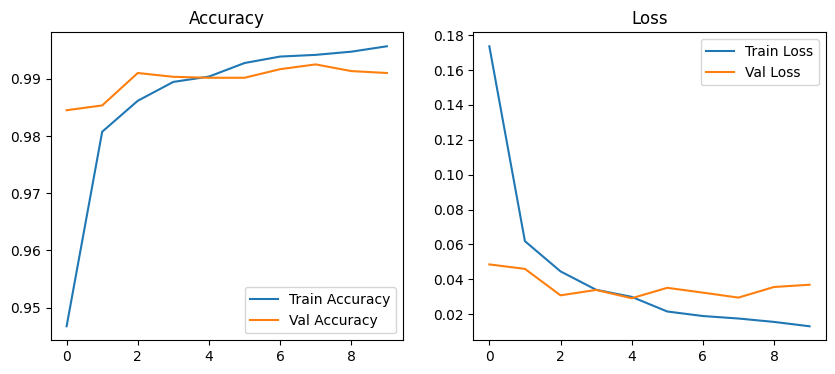

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9925 - loss: 0.0321
Test Accuracy: 0.9925000071525574
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 241ms/step


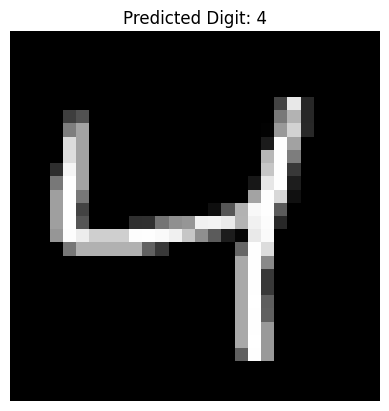

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step


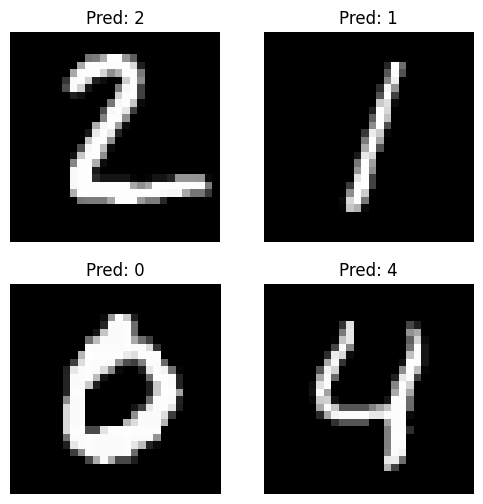

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step
Prediction from loaded model: 4


In [4]:
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf

from tensorflow.keras import layers, datasets, models
from tensorflow.keras.models import Sequential

# Load dataset
(train_images, train_labels), (test_images, test_labels) = datasets.mnist.load_data()

# Reshape and normalize
train_images = train_images.reshape((60000, 28, 28, 1)) / 255.0
test_images = test_images.reshape((10000, 28, 28, 1)) / 255.0

print("TRAIN IMAGES:", train_images.shape)
print("TEST IMAGES:", test_images.shape)

# Build CNN model
model = Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(10, activation='softmax')   
])

# Compile model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',  
    metrics=['accuracy']
)

# Train model
epochs = 10
history = model.fit(
    train_images,
    train_labels,
    epochs=epochs,
    validation_split=0.1,
    batch_size=32
)

# Plot accuracy and loss
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(acc, label='Train Accuracy')
plt.plot(val_acc, label='Val Accuracy')
plt.legend()
plt.title('Accuracy')

plt.subplot(1,2,2)
plt.plot(loss, label='Train Loss')
plt.plot(val_loss, label='Val Loss')
plt.legend()
plt.title('Loss')

plt.show()

# Evaluate on test data
test_loss, test_acc = model.evaluate(test_images, test_labels)
print("Test Accuracy:", test_acc)

# Predict single image
image = train_images[2].reshape(1,28,28,1)
prediction = np.argmax(model.predict(image), axis=1)

plt.imshow(image.reshape(28,28), cmap='gray')
plt.title(f"Predicted Digit: {prediction[0]}")
plt.axis('off')
plt.show()

# Predict multiple images
images = test_images[1:5]

plt.figure(figsize=(6,6))
for i, test_image in enumerate(images):
    img = test_image.reshape(1,28,28,1)
    pred = np.argmax(model.predict(img), axis=1)

    plt.subplot(2,2,i+1)
    plt.imshow(test_image.reshape(28,28), cmap='gray')
    plt.title(f"Pred: {pred[0]}")
    plt.axis('off')

plt.show()

# Save model
model.save("tf-cnn-model.h5")

# Load model
loaded_model = models.load_model("tf-cnn-model.h5")

# Test loaded model
image = train_images[2].reshape(1,28,28,1)
pred_loaded = np.argmax(loaded_model.predict(image), axis=1)

print("Prediction from loaded model:", pred_loaded[0])

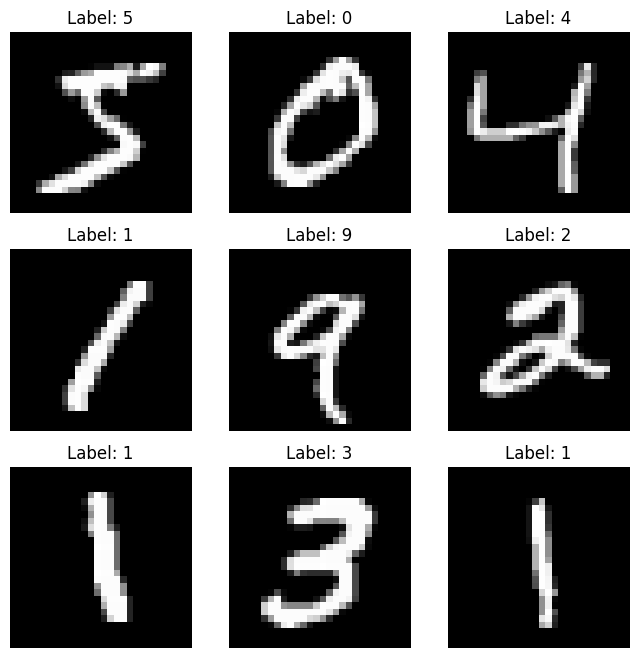

In [2]:
import matplotlib.pyplot as plt
from tensorflow.keras import datasets

# Load dataset
(train_images, train_labels), (test_images, test_labels) = datasets.mnist.load_data()

# Display first 9 images
plt.figure(figsize=(8,8))

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(train_images[i], cmap='gray')
    plt.title(f"Label: {train_labels[i]}")
    plt.axis('off')

plt.show()

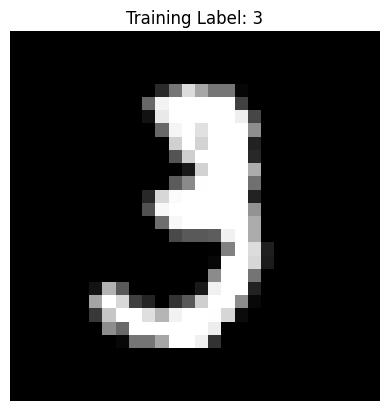

In [3]:
plt.imshow(train_images[10], cmap='gray')
plt.title(f"Training Label: {train_labels[10]}")
plt.axis('off')
plt.show()

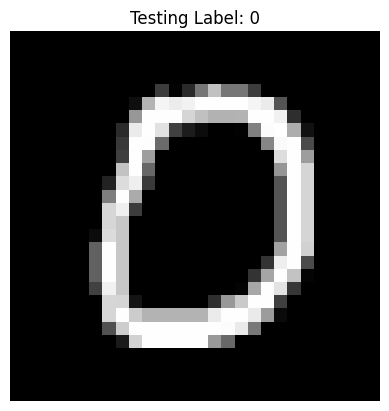

In [4]:
plt.imshow(test_images[10], cmap='gray')
plt.title(f"Testing Label: {test_labels[10]}")
plt.axis('off')
plt.show()